# 1. Perkenalan Dataset

Dataset yang digunakan pada project ini adalah **Online Shoppers Purchasing Intention Dataset**

Dataset:
https://www.kaggle.com/datasets/henrysue/online-shoppers-intention

## Latar Belakang

Dalam industri e-commerce, memahami perilaku pengunjung website sangat penting untuk meningkatkan conversion rate dan strategi pemasaran

Dataset ini berisi informasi perilaku pengunjung website seperti:
- bounce rate,
- exit rate,
- page value,
- visitor type,
- product related activity,
- dan berbagai informasi perilaku user lainnya

## Objective

Membangun model machine learning untuk memprediksi apakah pengunjung website e-commerce akan melakukan pembelian (`Revenue = TRUE`) atau tidak (`Revenue = FALSE`)

## Machine Learning Task

Binary Classification

## Target Variable

Revenue:
- TRUE  -> user melakukan pembelian
- FALSE -> user tidak melakukan pembelian



# 2. Import Library


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

import os

print("Library berhasil diimport.")


Library berhasil diimport.



# 3. Memuat Dataset


In [2]:
file_path = 'online_shoppers_intention.csv'

df = pd.read_csv(file_path)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print("Shape Dataset:", df.shape)

print("\nInformasi Dataset")
df.info()

Shape Dataset: (12330, 18)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330

In [4]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0



### Insight

Dataset tidak memiliki missing value yang signifikan sehingga preprocessing dapat lebih fokus pada:
- feature engineering,
- encoding,
- scaling,
- dan transformasi data



# 4. Exploratory Data Analysis (EDA)


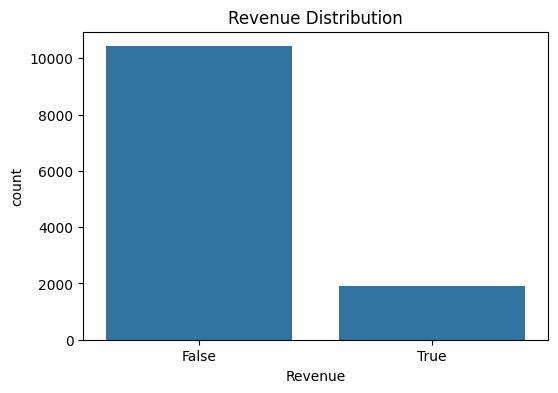

Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Revenue',
    data=df
)

plt.title('Revenue Distribution')
plt.show()

revenue_distribution = (
    df['Revenue']
    .value_counts(normalize=True) * 100
)

print(revenue_distribution)


### Insight

Dataset memiliki class imbalance dimana jumlah user yang tidak melakukan pembelian lebih besar dibandingkan user yang melakukan pembelian

In [6]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


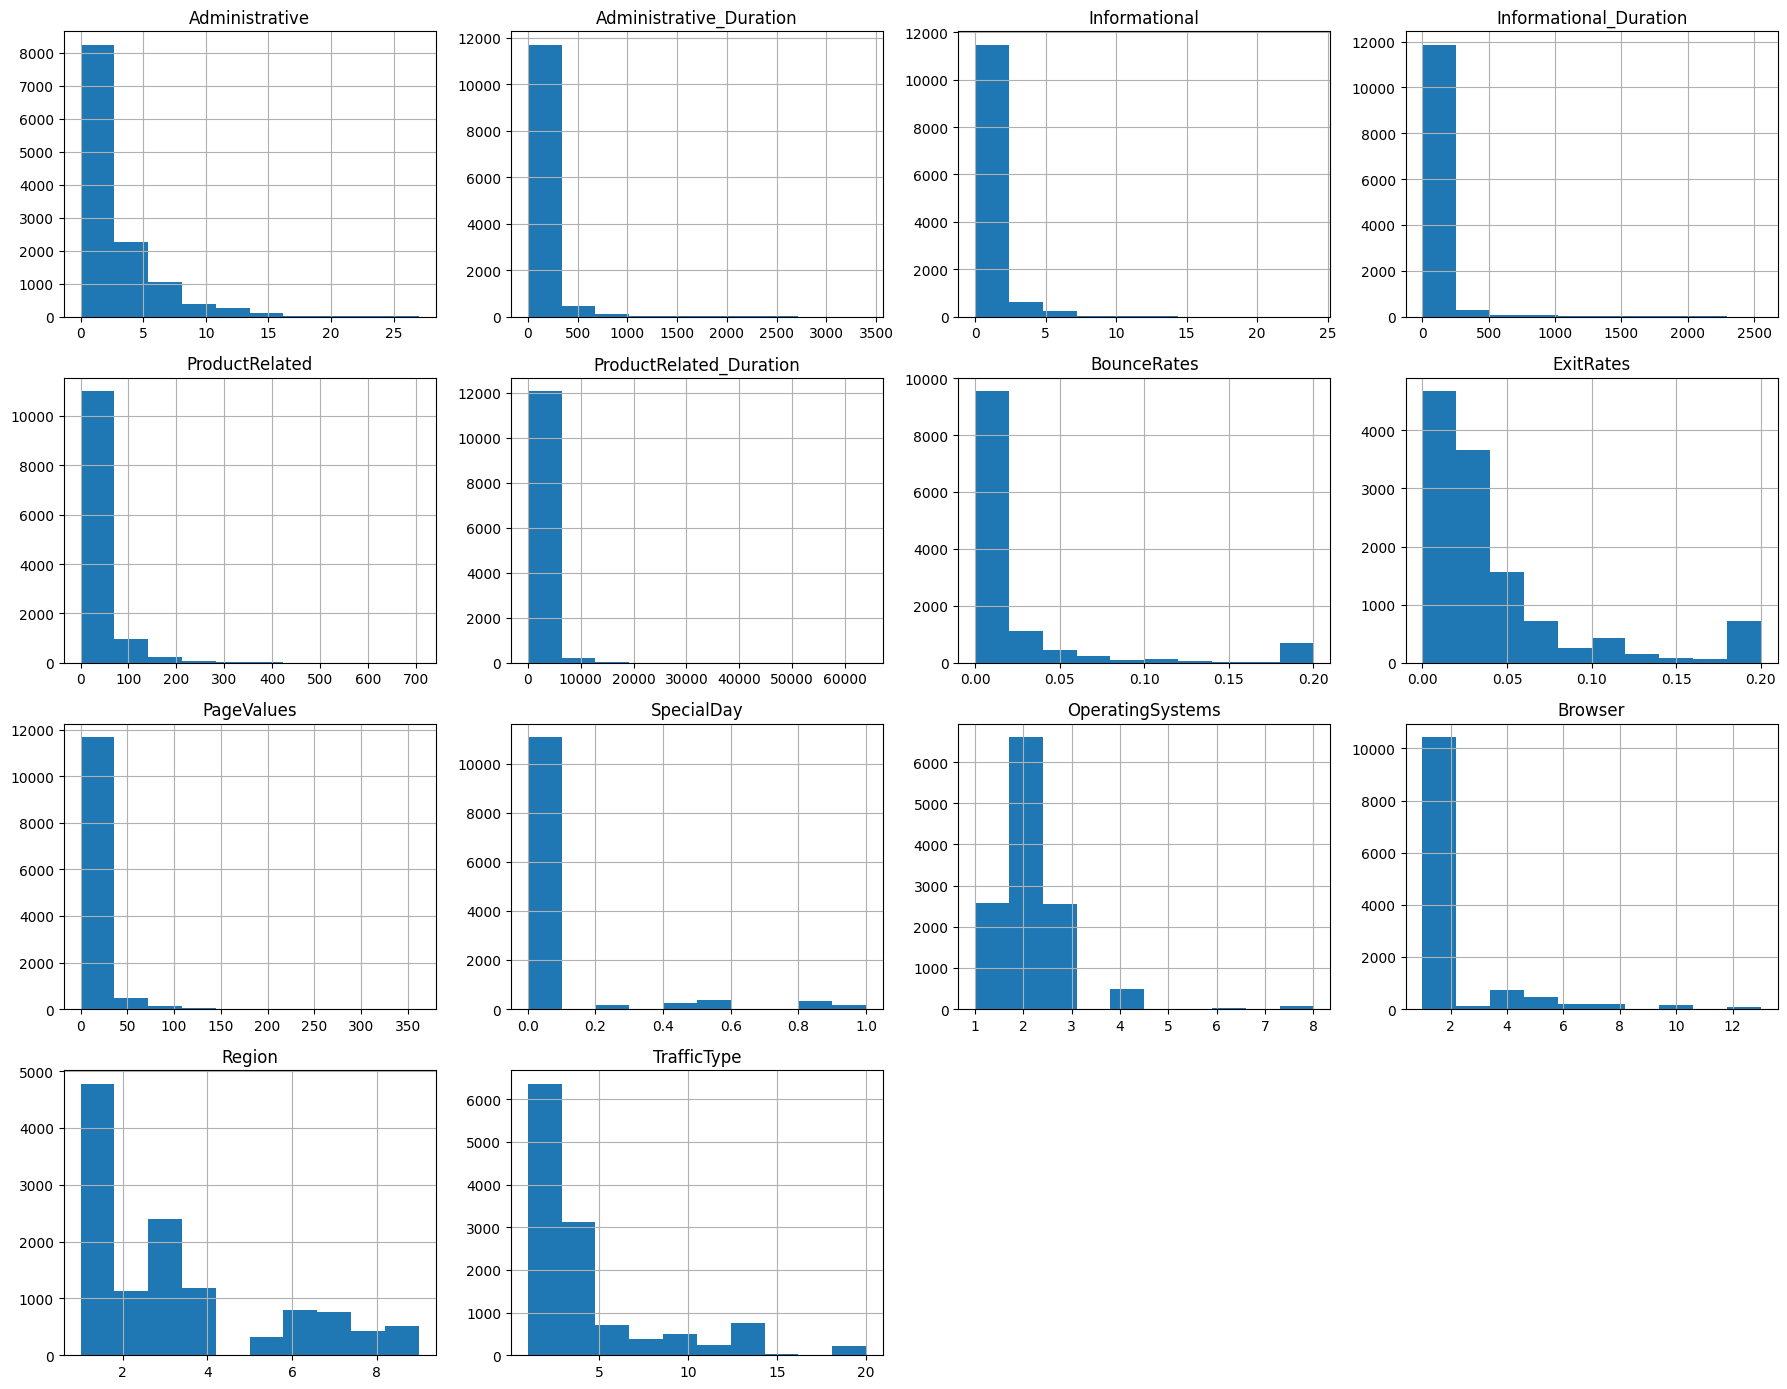

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(18,14)
)

plt.tight_layout()
plt.show()

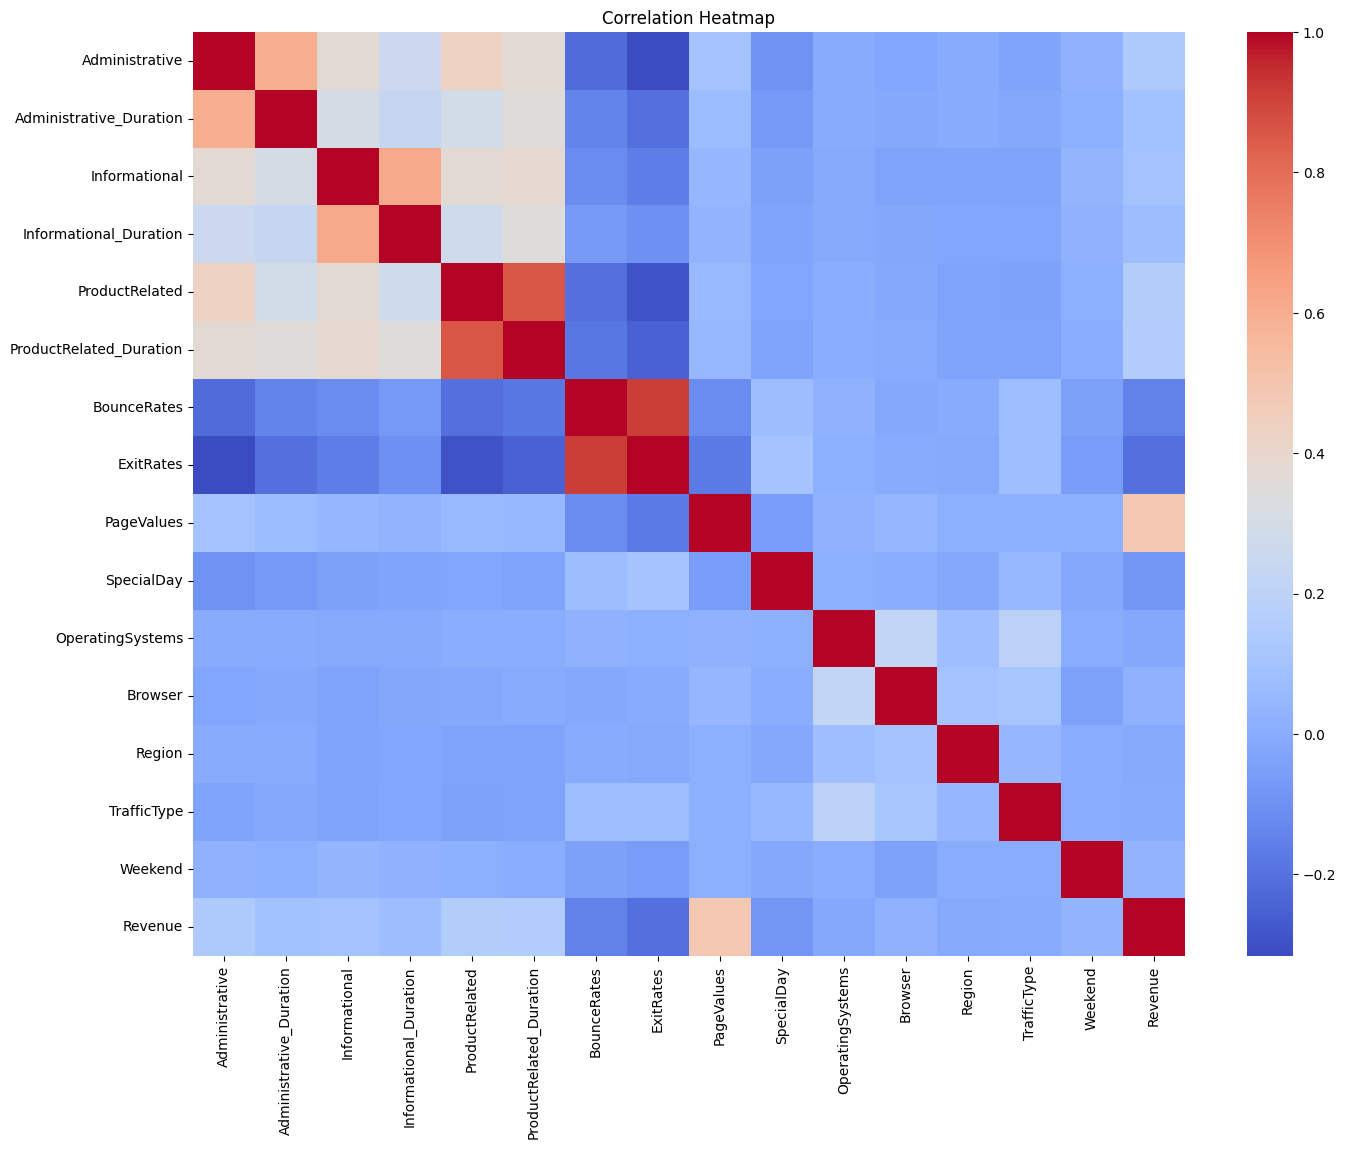

In [8]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

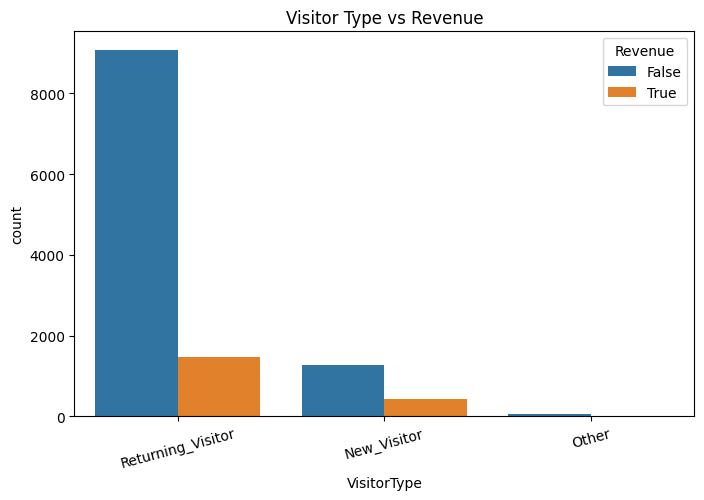

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='VisitorType',
    hue='Revenue',
    data=df
)

plt.title('Visitor Type vs Revenue')
plt.xticks(rotation=15)

plt.show()

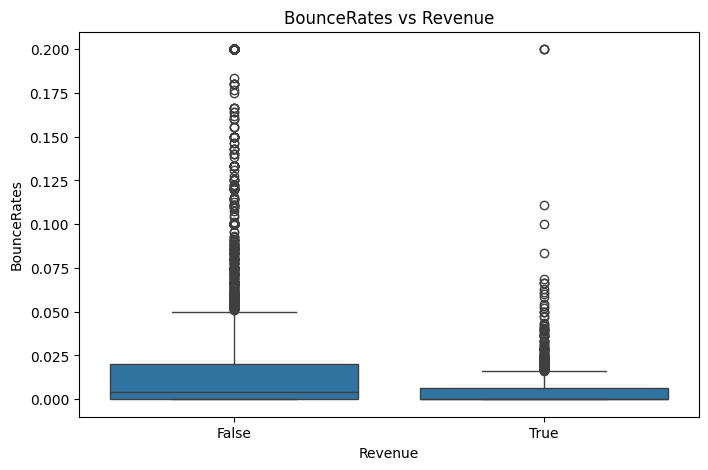

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Revenue',
    y='BounceRates',
    data=df
)

plt.title('BounceRates vs Revenue')

plt.show()


### EDA Insight

Berdasarkan hasil visualisasi:
- Returning Visitor memiliki kemungkinan purchase lebih tinggi.
- User dengan BounceRates tinggi cenderung tidak melakukan pembelian.
- Dataset memiliki pola perilaku user yang dapat dimanfaatkan untuk machine learning



# 5. Data Preprocessing



## 5.1 Copy Dataset


In [11]:
df = df.copy()

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



## 5.2 Feature Engineering


In [12]:

print("=== Feature Engineering ===")

df['EngagementScore'] = (
    df['PageValues'] +
    df['ProductRelated']
)

df['TotalDuration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

df['HighBounce'] = np.where(
    df['BounceRates'] > 0.02,
    1,
    0
)

df.head()

=== Feature Engineering ===


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,EngagementScore,TotalDuration,HighBounce
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,1,Returning_Visitor,False,False,1.0,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,2,1,2,Returning_Visitor,False,False,2.0,64.000000,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,4,1,9,3,Returning_Visitor,False,False,1.0,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,3,2,2,4,Returning_Visitor,False,False,2.0,2.666667,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,3,1,4,Returning_Visitor,True,False,10.0,627.500000,0



### Feature Engineering Insight

Feature engineering dilakukan untuk membantu model memahami perilaku user secara lebih baik.

Feature baru yang ditambahkan:
- EngagementScore
- TotalDuration
- HighBounce



## 5.3 Encoding Categorical Features


In [13]:
cat_cols = df.select_dtypes(include='object').columns

print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index(['Month', 'VisitorType'], dtype='object')


In [14]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,EngagementScore,TotalDuration,HighBounce
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,1,1,1,2,False,False,1.0,0.000000,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,2,2,1,2,2,False,False,2.0,64.000000,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,4,1,9,3,2,False,False,1.0,0.000000,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,3,2,2,4,2,False,False,2.0,2.666667,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,3,3,1,4,2,True,False,10.0,627.500000,0



## 5.4 Split Feature dan Target


In [15]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

print("Feature shape :", X.shape)
print("Target shape  :", y.shape)

Feature shape : (12330, 20)
Target shape  : (12330,)



## 5.5 Train Test Split


In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (9864, 20)
X_test shape : (2466, 20)



## 5.6 Feature Scaling


In [17]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling berhasil dilakukan.")


Scaling berhasil dilakukan.



# 6. Menyimpan Dataset Hasil Preprocessing


In [18]:
os.makedirs(
    'dataset_processed',
    exist_ok=True
)

df.to_csv(
    'dataset_processed/online_shoppers_processed.csv',
    index=False
)

print("Processed dataset berhasil disimpan.")


Processed dataset berhasil disimpan.



# 7. Kesimpulan

Berdasarkan hasil eksperimen:
- dataset berhasil dianalisis,
- preprocessing berhasil dilakukan,
- feature engineering berhasil ditambahkan,
- encoding berhasil dilakukan,
- dan dataset siap digunakan untuk proses training machine learning pada tahap berikutnya.
